##Лабораторна робота №1
##Класифікація даних засобами Scikit-learn

Мета роботи

Ознайомитися з базовим workflow задачі класифікації: від вибору та аналізу даних до навчання, налаштування, порівняння та оцінювання моделей машинного навчання з використанням бібліотеки Scikit-learn.

Датасет

Для виконання роботи обрано датасет Classification of Malwares (CLaMP).

Задача полягає у класифікації PE-файлів Windows на два класи:
- 0 — Benign (легітимний файл)
- 1 — Malware (шкідливий файл).

Для класифікації використовуються числові характеристики структури PE-файлів.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

DATA_URL = "https://raw.githubusercontent.com/maksymenkokyrylofb61mp/IAD-Lab1-CLaMP/main/ClaMP_Raw-5184.csv"

df = pd.read_csv(DATA_URL)


##1. Завантаження та первинний аналіз даних**

In [4]:
df.head()

,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,...,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,class
0,23117,144,3,0,4,0,65535,0,184,0,...,1194954,3,64,1048576,4096,1048576,4096,0,16,0
1,23117,144,3,0,4,0,65535,0,184,0,...,0,2,0,1048576,4096,1048576,4096,0,16,0
2,23117,144,3,0,4,0,65535,0,184,0,...,67688,2,320,1048576,4096,1048576,4096,0,16,0
3,23117,144,3,0,4,0,65535,0,184,0,...,113668,2,1344,1048576,4096,1048576,4096,0,16,0
4,23117,144,3,0,4,0,65535,0,184,0,...,69089,2,33088,262144,8192,1048576,4096,0,16,0


In [5]:
print("Розмір датасета:", df.shape)

print("\nНазви колонок:")
print(df.columns.tolist())

print("\nТипи даних:")
print(df.dtypes)

print("\nПерші 5 рядків:")
display(df.head())

Розмір датасета: (5184, 56)

Назви колонок:
['e_magic', 'e_cblp', 'e_cp', 'e_crlc', 'e_cparhdr', 'e_minalloc', 'e_maxalloc', 'e_ss', 'e_sp', 'e_csum', 'e_ip', 'e_cs', 'e_lfarlc', 'e_ovno', 'e_res', 'e_oemid', 'e_oeminfo', 'e_res2', 'e_lfanew', 'Machine', 'NumberOfSections', 'CreationYear', 'PointerToSymbolTable', 'NumberOfSymbols', 'SizeOfOptionalHeader', 'Characteristics', 'Magic', 'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion', 'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion', 'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage', 'SizeOfHeaders', 'CheckSum', 'Subsystem', 'DllCharacteristics', 'SizeOfStackReserve', 'SizeOfStackCommit', 'SizeOfHeapReserve', 'SizeOfHeapCommit', 'LoaderFlags', 'NumberOfRvaAndSizes', 'class']

Типи даних:
e_magic                   

,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,...,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,class
0,23117,144,3,0,4,0,65535,0,184,0,...,1194954,3,64,1048576,4096,1048576,4096,0,16,0
1,23117,144,3,0,4,0,65535,0,184,0,...,0,2,0,1048576,4096,1048576,4096,0,16,0
2,23117,144,3,0,4,0,65535,0,184,0,...,67688,2,320,1048576,4096,1048576,4096,0,16,0
3,23117,144,3,0,4,0,65535,0,184,0,...,113668,2,1344,1048576,4096,1048576,4096,0,16,0
4,23117,144,3,0,4,0,65535,0,184,0,...,69089,2,33088,262144,8192,1048576,4096,0,16,0


In [6]:
print(df["class"].value_counts())

print("\nУ відсотках:")
print(df["class"].value_counts(normalize=True) * 100)

class
1    2683
0    2501
Name: count, dtype: int64

У відсотках:
class
1    51.755401
0    48.244599
Name: proportion, dtype: float64


In [7]:
X = df.drop("class", axis=1)
y = df["class"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (5184, 55)
Target: (5184,)


Початковий датасет містить 5184 об'єкти та 55 колонок.  
Цільовою змінною є class.

Класи є достатньо збалансованими:
- Malware (1) — 2683 об'єкти;
- Benign (0) — 2501 об'єкт.

Ознаки представлені числовими значеннями, тому кодування категоріальних змінних не потрібне.

##2. Попередня обробка даних

Перевіримо датасет на наявність пропущених значень та дублікатів і виконаємо необхідне очищення.

In [8]:
missing_values = df.isnull().sum()

print("Колонки з пропущеними значеннями:")
print(missing_values[missing_values > 0])

print("\nЗагальна кількість пропущених значень:",
      df.isnull().sum().sum())

Колонки з пропущеними значеннями:
e_res     5184
e_res2    5184
dtype: int64

Загальна кількість пропущених значень: 10368


In [9]:
df = df.drop(columns=["e_res", "e_res2"])

print("Розмір після видалення порожніх колонок:", df.shape)
print("Загальна кількість пропущених значень:", df.isnull().sum().sum())

Розмір після видалення порожніх колонок: (5184, 54)
Загальна кількість пропущених значень: 0


In [10]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

print("Загальна кількість пропущених значень:", df.isnull().sum().sum())

Series([], dtype: int64)
Загальна кількість пропущених значень: 0


In [11]:
print("Кількість дублікатів:", df.duplicated().sum())

Кількість дублікатів: 624


In [12]:
df = df.drop_duplicates().reset_index(drop=True)

print("Розмір після видалення дублікатів:", df.shape)

X = df.drop("class", axis=1)
y = df["class"]

Розмір після видалення дублікатів: (4560, 54)


У колонках e_res та e_res2 усі 5184 значення були пропущені, тому ці ознаки не містили корисної інформації та були видалені.

Також було виявлено 624 дублікати, які було видалено.

Після очищення датасет містить 4560 об'єктів та 54 колонки. Пропущені значення та дублікати відсутні.

In [13]:
print("Розмір:", df.shape)
display(df.head())
print("\nРозподіл класів:")
print(df["class"].value_counts())
print("\nПропуски:", df.isnull().sum().sum())
print("Дублікати:", df.duplicated().sum())

Розмір: (4560, 54)


,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,...,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,class
0,23117,144,3,0,4,0,65535,0,184,0,...,1194954,3,64,1048576,4096,1048576,4096,0,16,0
1,23117,144,3,0,4,0,65535,0,184,0,...,0,2,0,1048576,4096,1048576,4096,0,16,0
2,23117,144,3,0,4,0,65535,0,184,0,...,67688,2,320,1048576,4096,1048576,4096,0,16,0
3,23117,144,3,0,4,0,65535,0,184,0,...,113668,2,1344,1048576,4096,1048576,4096,0,16,0
4,23117,144,3,0,4,0,65535,0,184,0,...,69089,2,33088,262144,8192,1048576,4096,0,16,0



Розподіл класів:
class
0    2488
1    2072
Name: count, dtype: int64

Пропуски: 0
Дублікати: 0


In [14]:
print(df["class"].value_counts())

print("\nУ відсотках:")
print(df["class"].value_counts(normalize=True) * 100)

class
0    2488
1    2072
Name: count, dtype: int64

У відсотках:
class
0    54.561404
1    45.438596
Name: proportion, dtype: float64


Після очищення розподіл класів залишається достатньо збалансованим:

- Benign — 2488 об'єктів (54.56%);
- Malware — 2072 об'єкти (45.44%).

Тому додаткове балансування класів не виконувалося.

## 3. Exploratory Data Analysis (EDA)

Оскільки датасет містить велику кількість ознак, для візуалізації було обрано декілька характеристик PE-файлів.

Побудуємо heatmap кореляцій, гістограми розподілу ознак та boxplot-и відносно цільового класу.

In [15]:
selected_features = [
    "NumberOfSections",
    "SizeOfCode",
    "SizeOfInitializedData",
    "AddressOfEntryPoint",
    "SizeOfImage",
    "CheckSum"
]

In [16]:
df[selected_features].describe()

,NumberOfSections,SizeOfCode,SizeOfInitializedData,AddressOfEntryPoint,SizeOfImage,CheckSum
count,4560.000000,4.560000e+03,4.560000e+03,4.560000e+03,4.560000e+03,4.560000e+03
mean,4.713377,9.856215e+05,3.047297e+05,1.750328e+05,6.150587e+05,2.637848e+06
std,1.976967,5.317461e+07,2.239578e+06,1.033939e+06,2.612817e+06,9.008558e+07
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000,9.728000e+03,1.228800e+04,6.867500e+03,7.782400e+04,0.000000e+00
50%,5.000000,4.096000e+04,4.812800e+04,1.945800e+04,1.556480e+05,9.668700e+04
75%,5.000000,1.546240e+05,1.177600e+05,9.208300e+04,4.014080e+05,2.525022e+05
max,34.000000,3.590647e+09,8.116634e+07,4.240387e+07,8.125235e+07,4.294967e+09


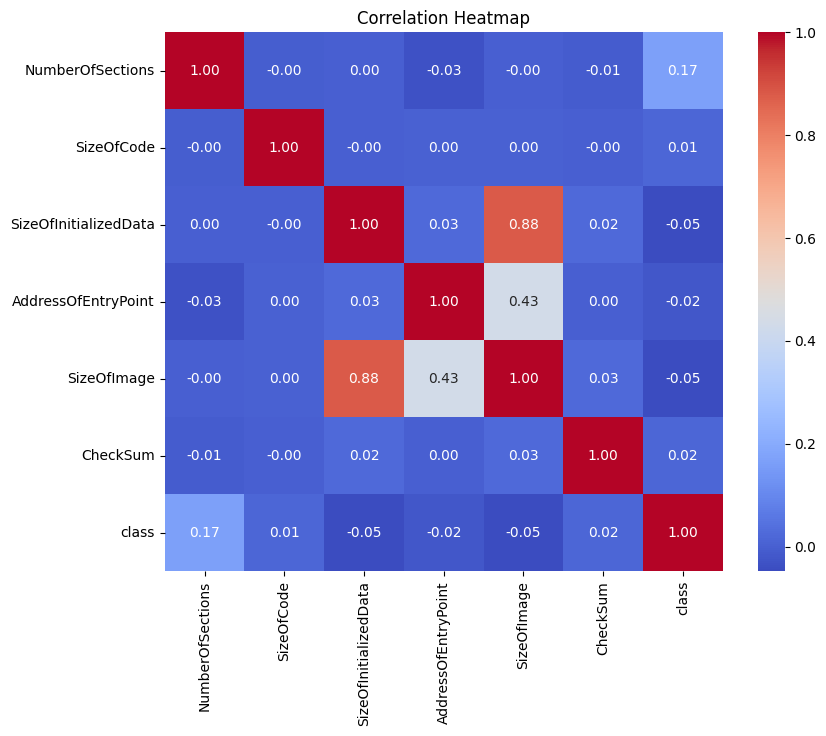

In [17]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    df[selected_features + ["class"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

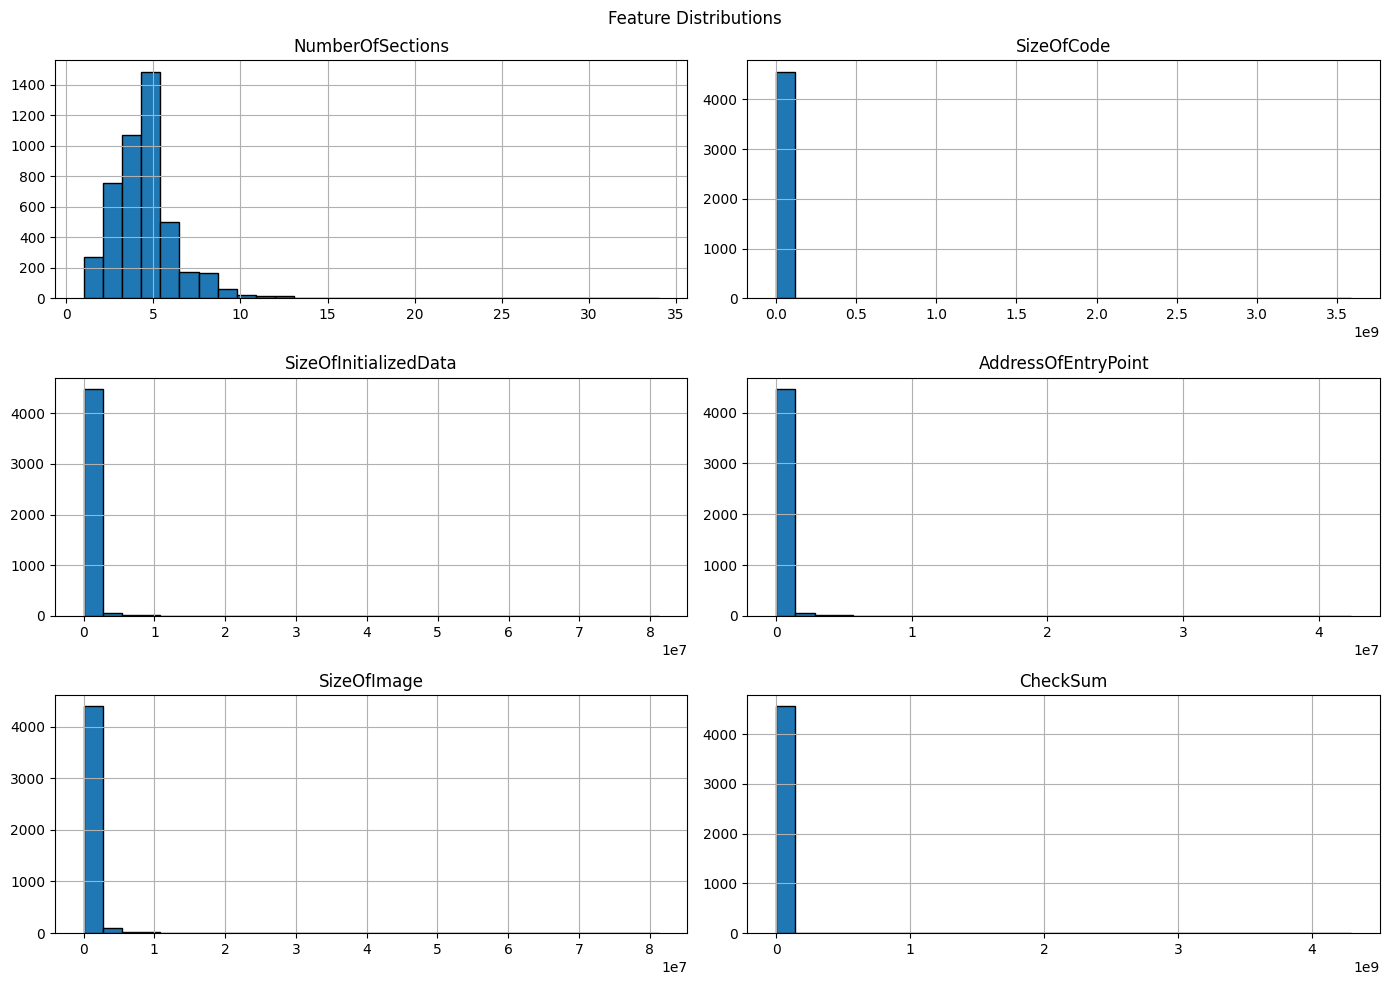

In [18]:
df[selected_features].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

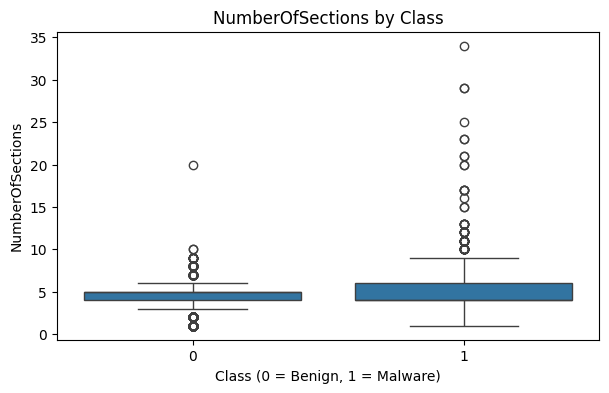

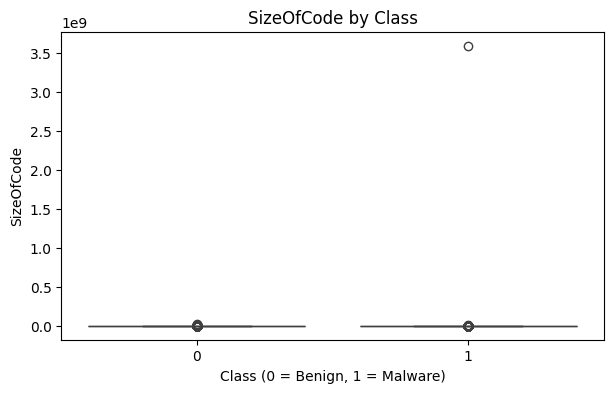

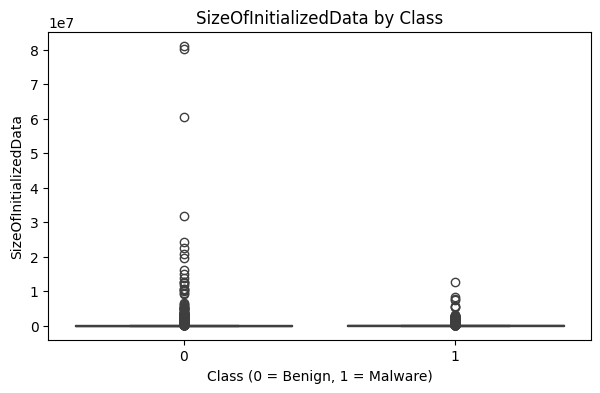

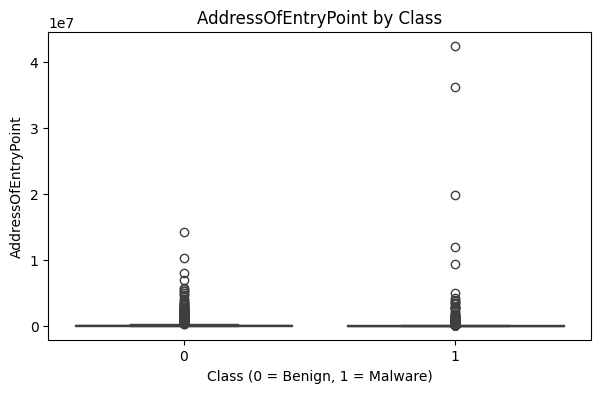

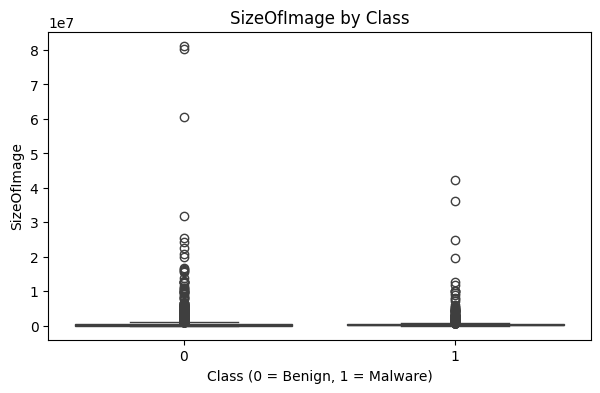

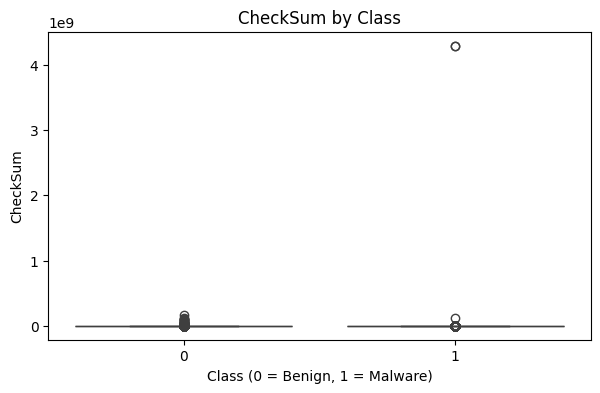

In [19]:
for feature in selected_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="class",
        y=feature
    )

    plt.title(f"{feature} by Class")
    plt.xlabel("Class (0 = Benign, 1 = Malware)")
    plt.ylabel(feature)

    plt.show()

### Висновки з EDA

Кореляційна матриця показує, що більшість обраних ознак мають слабкий лінійний зв'язок із цільовою змінною class.

Серед обраних ознак найбільшу кореляцію з класом має NumberOfSections. Також спостерігається сильний зв'язок між деякими характеристиками розміру PE-файлів.

Гістограми та boxplot-и показують асиметричний розподіл частини ознак та наявність значної кількості викидів.

## 4. Підготовка даних до навчання

Дані розділено на навчальну та тестову вибірки у співвідношенні 80% / 20%.

Для збереження співвідношення класів використано параметр stratify=y.

Для алгоритмів kNN та SVM виконано стандартизацію ознак за допомогою StandardScaler, оскільки ці алгоритми чутливі до масштабу значень.

In [20]:
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3648, 53)
X_test: (912, 53)
y_train: (3648,)
y_test: (912,)


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабування виконано")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Масштабування виконано
X_train_scaled: (3648, 53)
X_test_scaled: (912, 53)


## 5. Навчання моделей

Для порівняння було навчено п'ять класифікаторів:
- k-Nearest Neighbors;
- Decision Tree;
- Support Vector Machine;
- Random Forest;
- AdaBoost.

In [22]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("kNN Accuracy:", knn_accuracy)

kNN Accuracy: 0.9627192982456141


### Підбір гіперпараметрів kNN

Для вибору оптимального значення n_neighbors використано GridSearchCV з 5-кратною крос-валідацією.

In [23]:
param_grid_knn = {
    "n_neighbors": range(1, 21)
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="accuracy"
)

grid_knn.fit(X_train_scaled, y_train)

best_k = grid_knn.best_params_["n_neighbors"]

print("Найкраще n_neighbors:", best_k)
print("Найкраща CV Accuracy:", grid_knn.best_score_)

Найкраще n_neighbors: 1
Найкраща CV Accuracy: 0.9613495687468289


Найкращим значенням виявилося n_neighbors = 1.  
Середня accuracy при 5-кратній крос-валідації становила приблизно 96.13%.

In [24]:
knn = grid_knn.best_estimator_

y_pred_knn = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("Фінальна kNN Accuracy на test:", knn_accuracy)

Фінальна kNN Accuracy на test: 0.9747807017543859


In [25]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.9616228070175439


In [26]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9890350877192983


In [27]:
ada = AdaBoostClassifier(
    random_state=42
)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

ada_accuracy = accuracy_score(y_test, y_pred_ada)

print("AdaBoost Accuracy:", ada_accuracy)

AdaBoost Accuracy: 0.9528508771929824


### Підбір гіперпараметрів SVM

Для SVM за допомогою GridSearchCV виконано пошук оптимальних значень параметрів C та gamma з використанням 5-кратної крос-валідації.

In [28]:
param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

grid_svm = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid_svm,
    cv=5,
    scoring="accuracy"
)

grid_svm.fit(X_train_scaled, y_train)

print("Найкращі параметри:", grid_svm.best_params_)
print("Найкраща CV Accuracy:", grid_svm.best_score_)

Найкращі параметри: {'C': 100, 'gamma': 0.1}
Найкраща CV Accuracy: 0.9539477986357744


Найкращими параметрами SVM виявилися:

- C = 100;
- gamma = 0.1.

Середня accuracy при крос-валідації становила приблизно **95.39%**.

In [29]:
svm = grid_svm.best_estimator_

y_pred_svm = svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy на test:", svm_accuracy)

SVM Accuracy на test: 0.9627192982456141


In [30]:
results = pd.DataFrame({
    "Model": [
        "kNN",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "AdaBoost"
    ],
    "Accuracy": [
        knn_accuracy,
        tree_accuracy,
        svm_accuracy,
        rf_accuracy,
        ada_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy
0,Random Forest,0.989035
1,kNN,0.974781
2,SVM,0.962719
3,Decision Tree,0.961623
4,AdaBoost,0.952851


## 6. Порівняння та оцінювання моделей

Порівняємо accuracy усіх навчених моделей на тестовій вибірці, а також проаналізуємо classification_report та confusion_matrix.

In [31]:
predictions = {
    "kNN": y_pred_knn,
    "Decision Tree": y_pred_tree,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "AdaBoost": y_pred_ada
}

for name, y_pred in predictions.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malware"]
    ))

kNN
              precision    recall  f1-score   support

      Benign       0.98      0.97      0.98       498
     Malware       0.96      0.98      0.97       414

    accuracy                           0.97       912
   macro avg       0.97      0.98      0.97       912
weighted avg       0.97      0.97      0.97       912

Decision Tree
              precision    recall  f1-score   support

      Benign       0.97      0.96      0.96       498
     Malware       0.95      0.96      0.96       414

    accuracy                           0.96       912
   macro avg       0.96      0.96      0.96       912
weighted avg       0.96      0.96      0.96       912

SVM
              precision    recall  f1-score   support

      Benign       0.98      0.95      0.97       498
     Malware       0.94      0.98      0.96       414

    accuracy                           0.96       912
   macro avg       0.96      0.96      0.96       912
weighted avg       0.96      0.96      0.96       91

За результатами тестування найкращі показники продемонстрував Random Forest.

Для обох класів модель має precision, recall та F1-score близько 0.99, що свідчить про високу якість класифікації як легітимних, так і шкідливих файлів.

kNN також показав високий результат, зокрема recall для класу Malware становить приблизно 0.98.

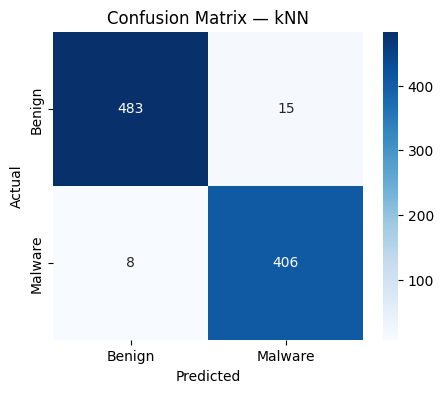

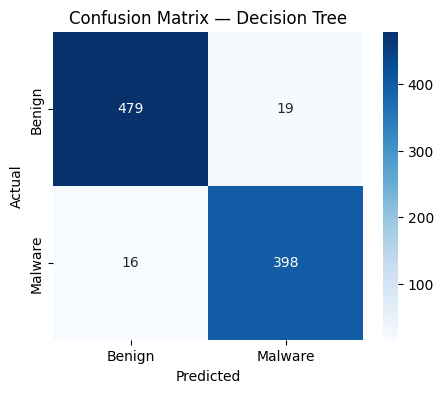

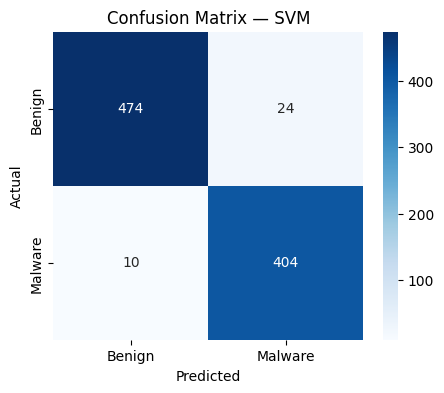

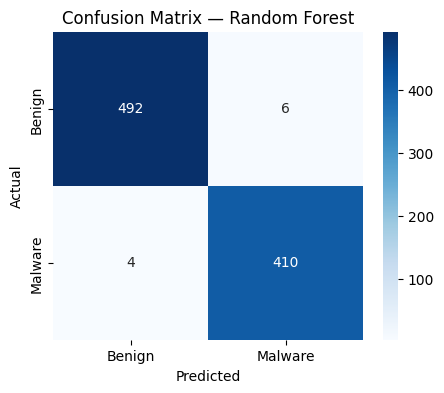

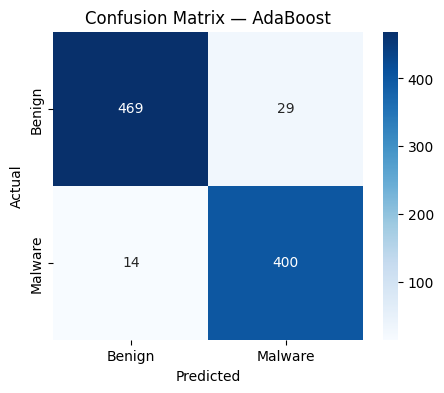

In [32]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malware"],
        yticklabels=["Benign", "Malware"]
    )

    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

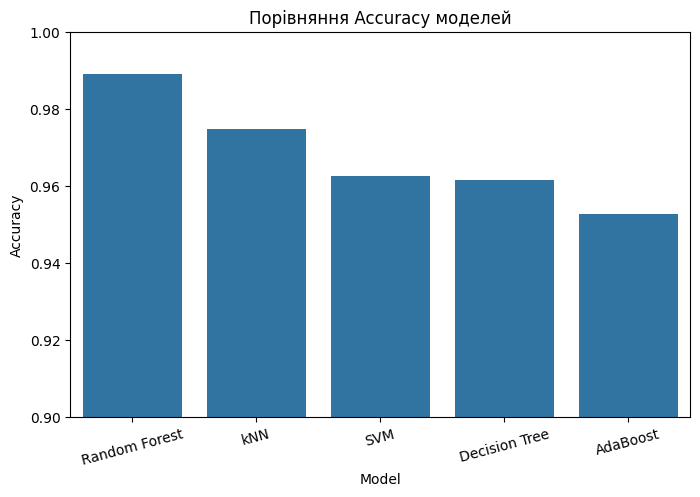

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0.9, 1.0)
plt.title("Порівняння Accuracy моделей")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=15)

plt.show()

## Висновок

У ході роботи було досліджено датасет CLaMP та навчено п'ять моделей машинного навчання для класифікації PE-файлів Windows на Benign та Malware.

Отримані результати:

- Random Forest — 98.90%
- kNN — 97.48%
- SVM — 96.27%
- Decision Tree — 96.16%
- AdaBoost — 95.29%

Найкращий результат показав Random Forest з accuracy приблизно 98.90% та високими значеннями precision, recall і F1-score для обох класів.

На мою думку, Random Forest найкраще підходить для цього датасета, оскільки ансамбль дерев рішень добре працює зі складними нелінійними залежностями між великою кількістю ознак та показав найкращу якість класифікації серед протестованих моделей.